In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

**Task 1: Dataset Understanding**

In [69]:
df=pd.read_csv(r"C:\Users\Ansh Verma\Downloads\Zomato_with_city_cuisine.csv")
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),city,cuisine
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet,Delhi,Chinese
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet,Bangalore,Fast Food
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet,Pune,Chinese
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet,Chandigarh,Cafe
4,Grand Village,No,No,3.8/5,166,600,Buffet,Chandigarh,Cafe


**Task 2: Data Cleaning**

In [70]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
city                           0
cuisine                        0
dtype: int64

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
 7   city                         148 non-null    object
 8   cuisine                      148 non-null    object
dtypes: int64(2), object(7)
memory usage: 10.5+ KB


In [72]:
df.drop_duplicates(inplace=True)

In [73]:
df['rate'] = df['rate'].str.replace('/5','', regex=False)
df['rate'] = pd.to_numeric(df['rate'])

In [74]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),city,cuisine
0,Jalsa,Yes,Yes,4.1,775,800,Buffet,Delhi,Chinese
1,Spice Elephant,Yes,No,4.1,787,800,Buffet,Bangalore,Fast Food
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet,Pune,Chinese
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet,Chandigarh,Cafe
4,Grand Village,No,No,3.8,166,600,Buffet,Chandigarh,Cafe


**Task 3: Descriptive Statistics**

In [75]:
num_cols = ['rate','votes','approx_cost(for two people)']
for col in num_cols:
    print("\nColumn:", col)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Std Dev:", df[col].std())
    print("Variance:", df[col].var())


Column: rate
Mean: 3.6331081081081082
Median: 3.7
Mode: 3.8
Std Dev: 0.4022705140380333
Variance: 0.16182156646442358

Column: votes
Mean: 264.81081081081084
Median: 43.5
Mode: 0
Std Dev: 653.6769506420574
Variance: 427293.55580069864

Column: approx_cost(for two people)
Mean: 418.2432432432432
Median: 400.0
Mode: 300
Std Dev: 223.085097750588
Variance: 49766.96083838941


**TASK-4:**

**Task 4: Restaurant Distribution Analysis**

In [76]:
print(df['city'].value_counts().head(1))
top_cities=df['city'].value_counts().head(10)
print(top_cities)

city
Delhi    20
Name: count, dtype: int64
city
Delhi         20
Chandigarh    19
Jaipur        17
Pune          17
Chennai       15
Mumbai        13
Hyderabad     13
Lucknow       13
Bangalore     12
Kolkata        9
Name: count, dtype: int64


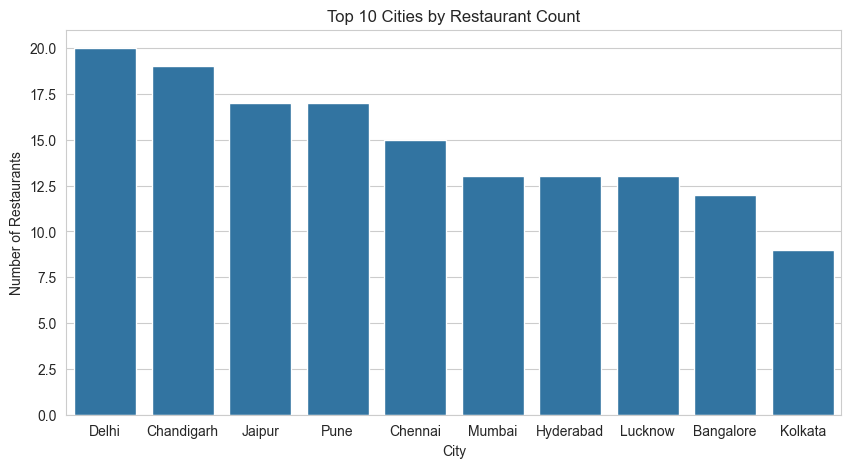

In [77]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=top_cities.index,
    y=top_cities.values
)
plt.title("Top 10 Cities by Restaurant Count")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.show()

**Task 5: Cuisine Analysis**

In [78]:
top_cuisines = df['cuisine'].value_counts().head(10)
print(top_cuisines)

cuisine
Italian         22
South Indian    19
Cafe            18
North Indian    18
Desserts        17
Biryani         14
Chinese         13
Street Food     10
Fast Food        9
Continental      8
Name: count, dtype: int64


In [79]:
highest_rated = df.groupby('cuisine')['rate'].max().head(10)
print(highest_rated)

cuisine
Biryani         4.1
Cafe            4.4
Chinese         4.1
Continental     4.2
Desserts        4.2
Fast Food       4.6
Italian         4.4
North Indian    4.2
South Indian    4.3
Street Food     4.1
Name: rate, dtype: float64


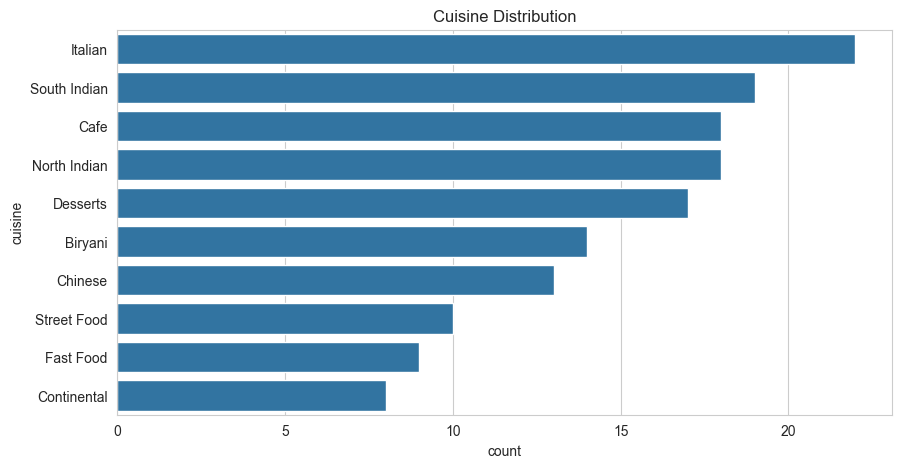

In [80]:
plt.figure(figsize=(10,5))
sns.countplot(
    y='cuisine',
    data=df,
    order=df['cuisine'].value_counts().index
)
plt.title("Cuisine Distribution")
plt.show()

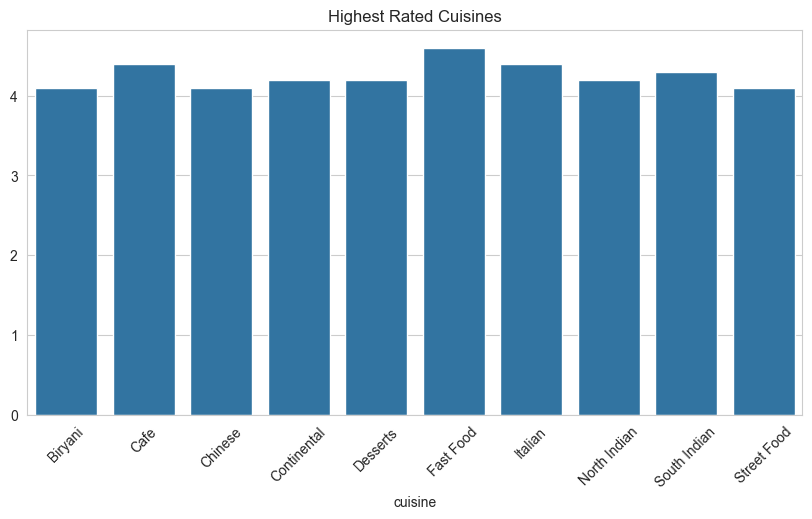

In [81]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=highest_rated.index[:10],
    y=highest_rated.values[:10]
)
plt.xticks(rotation=45)
plt.title("Highest Rated Cuisines")
plt.show()

**TASK-6: RATING ANALYSIS**

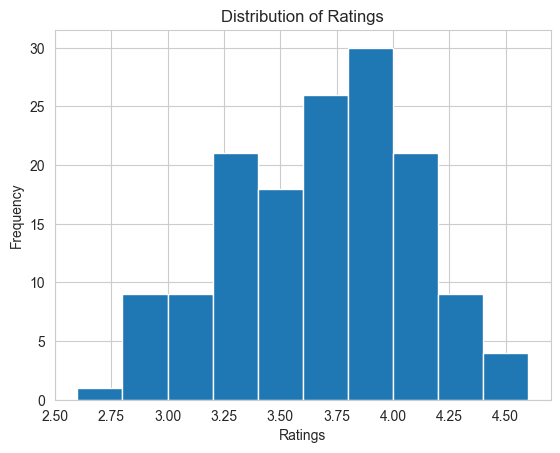

skewness of ratings: -0.15604931960897167


In [82]:
plt.hist(df['rate'], bins=10)
plt.xlabel("Ratings")
plt.ylabel("Frequency")
plt.title("Distribution of Ratings")
plt.show()
print("skewness of ratings:",df['rate'].skew(numeric_only=True))

In [84]:
Q1 = df['rate'].quantile(0.25)
Q3 = df['rate'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers = df[
    (df['rate'] < lower) |
    (df['rate'] > upper)
]
print(outliers)

Empty DataFrame
Columns: [name, online_order, book_table, rate, votes, approx_cost(for two people), listed_in(type), city, cuisine]
Index: []


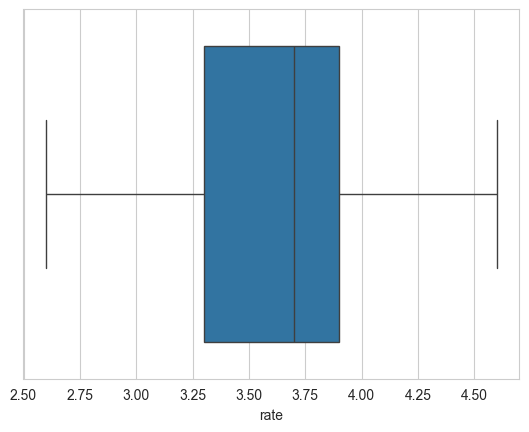

In [85]:
sns.boxplot(x=df['rate'])
plt.show()

**Task 7: Online Delivery Analysis**

In [86]:
print(df['online_order'].value_counts())

online_order
No     90
Yes    58
Name: count, dtype: int64


In [87]:
avg_rating = df.groupby('online_order')['rate'].mean()
print(avg_rating)

online_order
No     3.487778
Yes    3.858621
Name: rate, dtype: float64


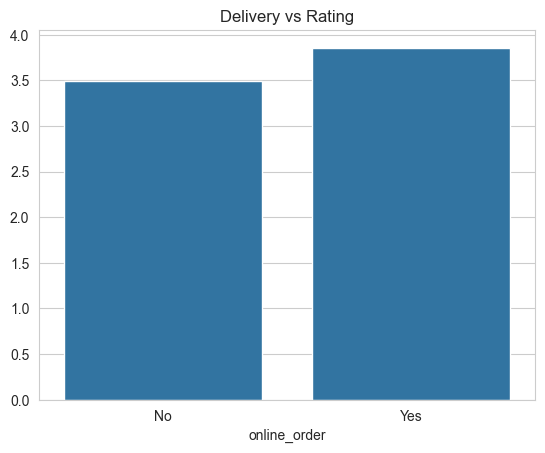

In [88]:
sns.barplot(
    x=avg_rating.index,
    y=avg_rating.values
)
plt.title("Delivery vs Rating")
plt.show()

**Task 8: Cost Analysis**

In [89]:
print("Average Cost:",df['approx_cost(for two people)'].mean())

Average Cost: 418.2432432432432


In [92]:
expensive = df.sort_values(by='approx_cost(for two people)',ascending=False)
print(expensive[['name','city','cuisine','approx_cost(for two people)']].head(10))

                     name        city       cuisine  \
97   Ayda Persian Kitchen      Mumbai  South Indian   
22        Cafe Coffee Day     Chennai       Chinese   
119         K27 - The Pub     Lucknow   Continental   
48          Beijing Bites       Delhi       Italian   
63        Jeet Restaurant        Pune       Italian   
16           Catch-up-ino      Jaipur   Street Food   
60          Peppy Peppers  Chandigarh       Italian   
14        San Churro Cafe  Chandigarh  North Indian   
0                   Jalsa       Delhi       Chinese   
57                 Wamama  Chandigarh     Fast Food   

     approx_cost(for two people)  
97                           950  
22                           900  
119                          900  
48                           850  
63                           850  
16                           800  
60                           800  
14                           800  
0                            800  
57                           800  


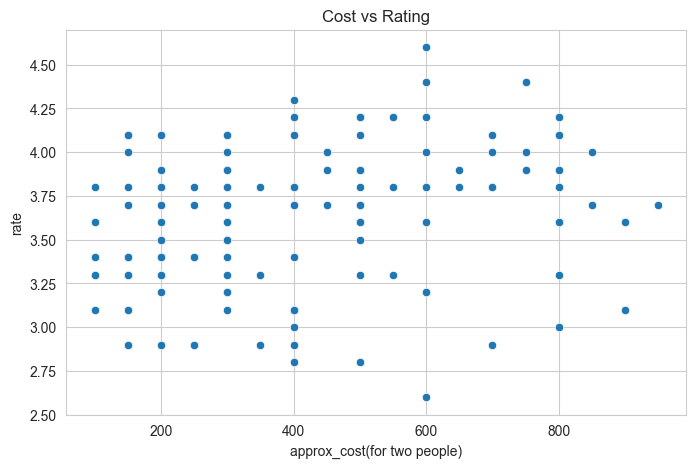

In [93]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='approx_cost(for two people)',
    y='rate',
    data=df
)
plt.title("Cost vs Rating")
plt.show()

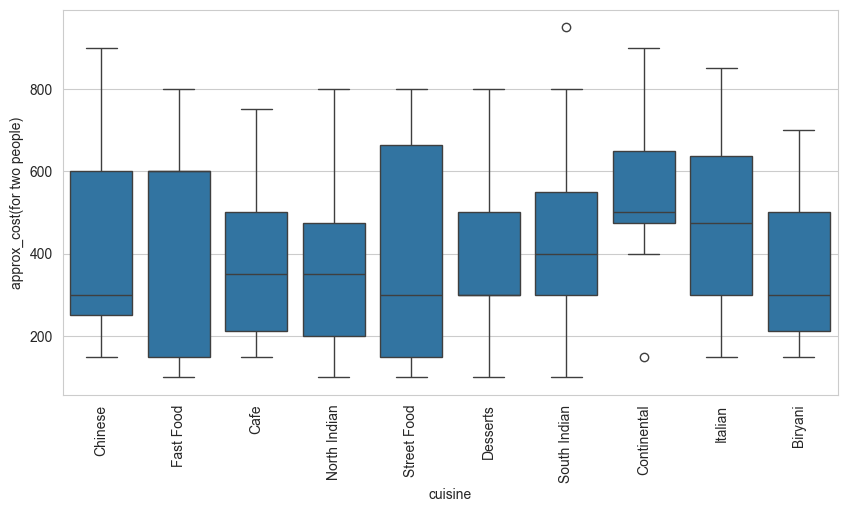

In [94]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x='cuisine',
    y='approx_cost(for two people)',
    data=df
)
plt.xticks(rotation=90)
plt.show()

**Task 9: Correlation Analysis**

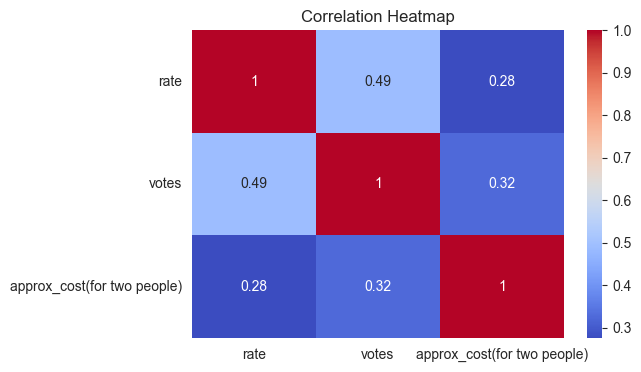

In [95]:
corr = df[
    ['rate',
     'votes',
     'approx_cost(for two people)']
].corr()
plt.figure(figsize=(6,4))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

In [96]:
corr.unstack().sort_values(ascending=False)

rate                         rate                           1.000000
votes                        votes                          1.000000
approx_cost(for two people)  approx_cost(for two people)    1.000000
votes                        rate                           0.489844
rate                         votes                          0.489844
approx_cost(for two people)  votes                          0.324372
votes                        approx_cost(for two people)    0.324372
rate                         approx_cost(for two people)    0.275216
approx_cost(for two people)  rate                           0.275216
dtype: float64

**Task 10: Feature Engineering**

In [97]:
def cost_category(cost):
    if cost <= 300:
        return "Budget"

    elif cost <= 600:
        return "Moderate"

    elif cost <= 1000:
        return "Premium"

    else:
        return "Luxury"
df['Cost_Category'] = df[
    'approx_cost(for two people)'
].apply(cost_category)

In [98]:
def rating_category(rate):
    if rate < 3:
        return "Poor"

    elif rate < 3.5:
        return "Average"

    elif rate < 4:
        return "Good"

    else:
        return "Excellent"

df['Rating_Category'] = df['rate'].apply(rating_category)

In [99]:
print(df['Cost_Category'].value_counts())
print(df['Rating_Category'].value_counts())

Cost_Category
Budget      67
Moderate    54
Premium     27
Name: count, dtype: int64
Rating_Category
Good         62
Average      42
Excellent    34
Poor         10
Name: count, dtype: int64


**Task 11: Business Insights**

Insights are:
1. Delhi has the highest number of restaurants, followed by Chandigarh.
2. Italian cuisine is the most frequently available cuisine in the dataset.
3. Biryani is the highest-rated cuisine with an average rating of approximately 4.1.
4. Most restaurant ratings fall between 3.3 and 4.0, indicating generally positive customer feedback.
5. Restaurants with higher vote counts tend to receive better ratings, suggesting a positive relationship between popularity and customer satisfaction.

Recommendations:
1. Expand online delivery services for more restaurants.
2. Promote top-rated cuisines in advertisements.
3. Encourage low-rated restaurants to improve service quality through customer feedback analysis.